COVID-19 DATA ANALYSIS PROJECT

Dataset Loaded Successfully

========== FIRST FIVE ROWS ==========
         Date Country/Region Province/State       Lat       Long  Confirmed  \
0  2020-01-22    Afghanistan            NaN  33.93911  67.709953          0   
1  2020-01-23    Afghanistan            NaN  33.93911  67.709953          0   
2  2020-01-24    Afghanistan            NaN  33.93911  67.709953          0   
3  2020-01-25    Afghanistan            NaN  33.93911  67.709953          0   
4  2020-01-26    Afghanistan            NaN  33.93911  67.709953          0   

   Recovered  Deaths  
0        0.0       0  
1        0.0       0  
2        0.0       0  
3        0.0       0  
4        0.0       0  

========== LAST FIVE ROWS ==========
             Date Country/Region Province/State        Lat       Long  \
72085  2020-10-13       Zimbabwe            NaN -19.015438  29.154857   
72086  2020-10-14       Zimbabwe            NaN -19.015438  29.154857   
72087  2020-10-15       Zimbabw

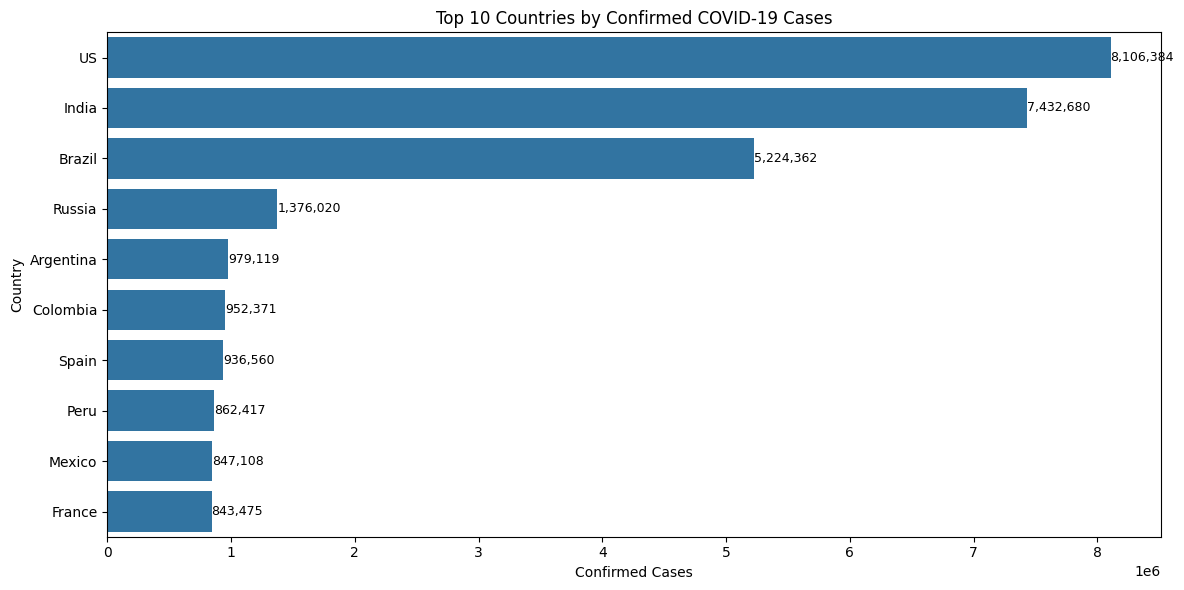

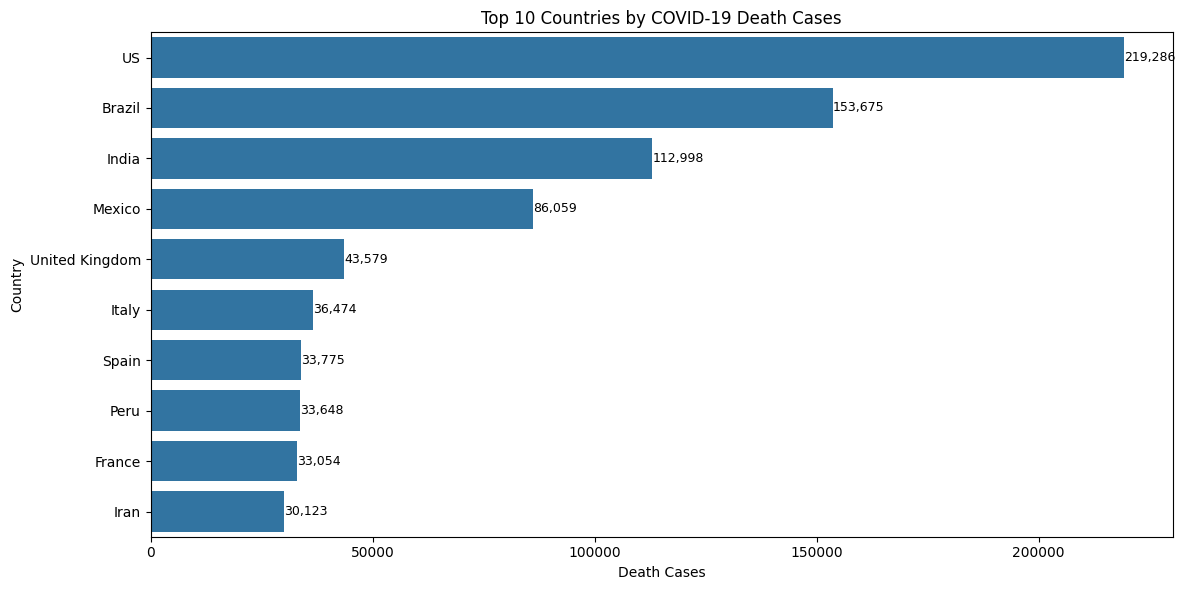

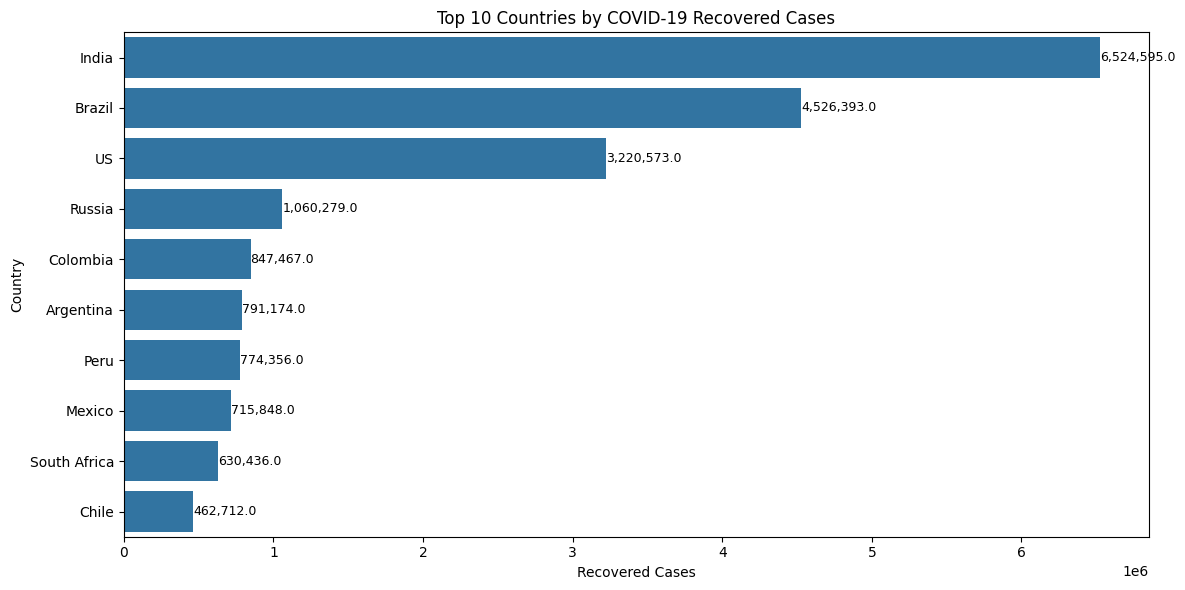

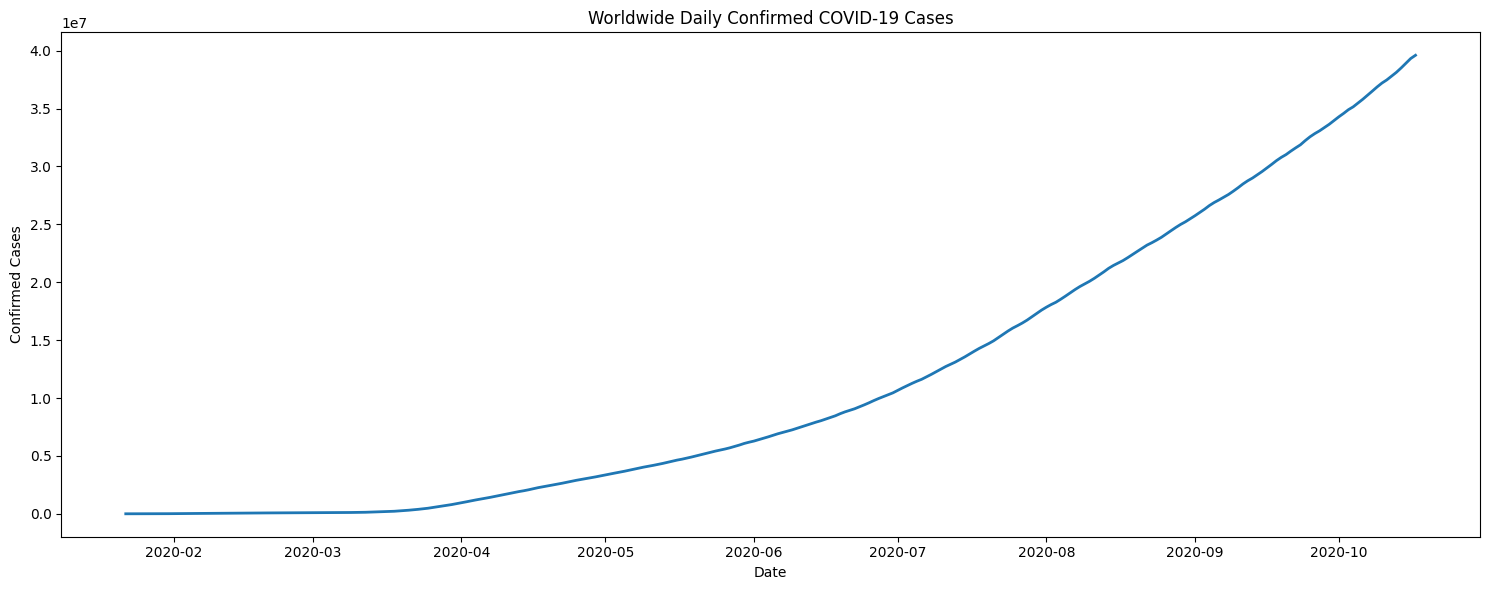

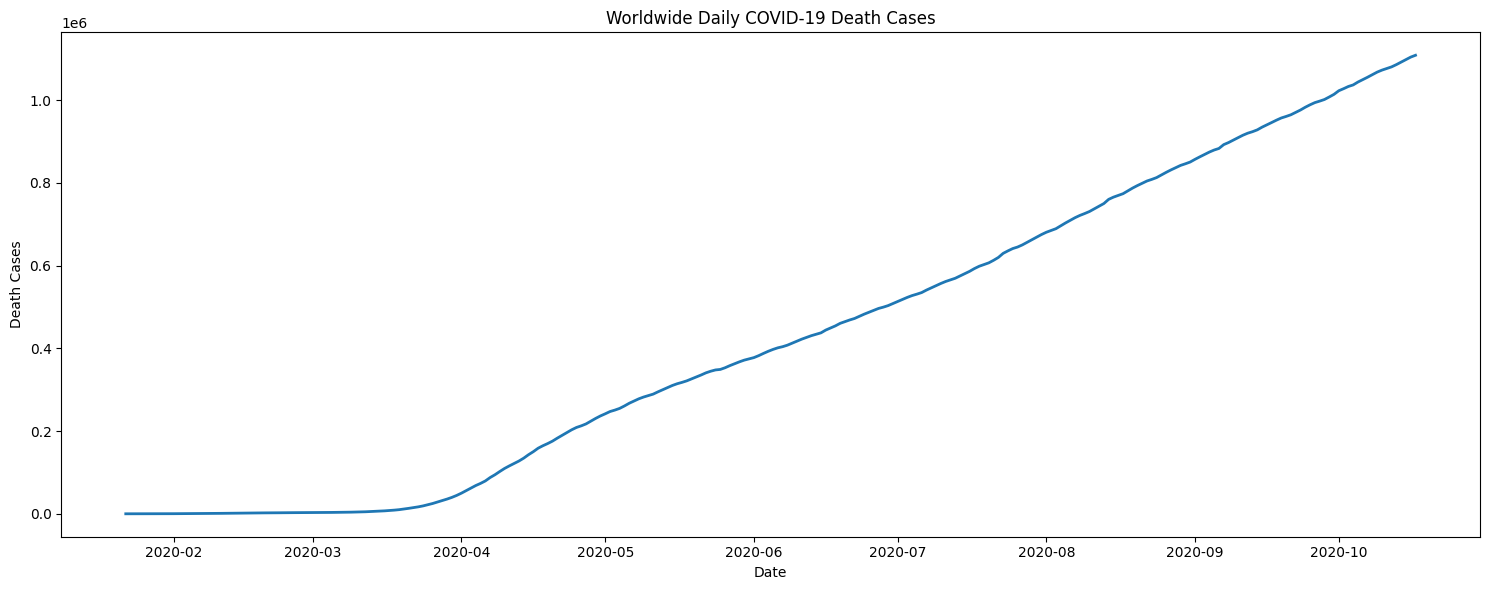

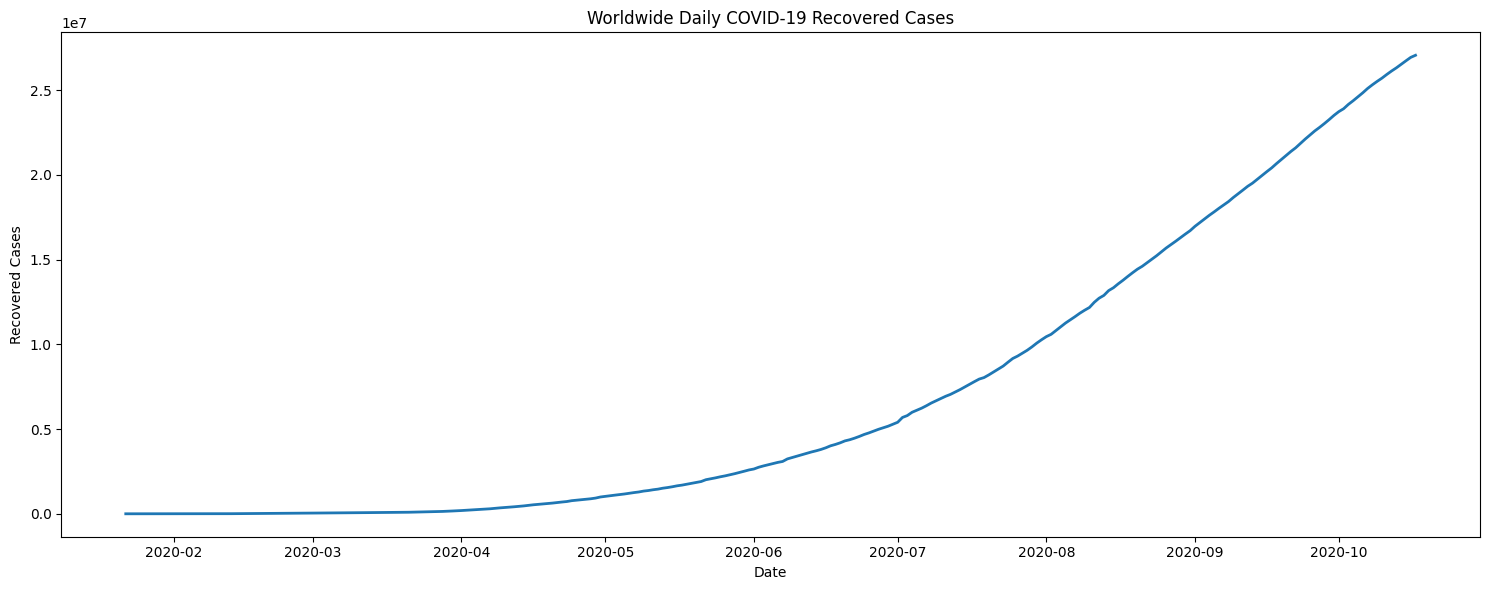

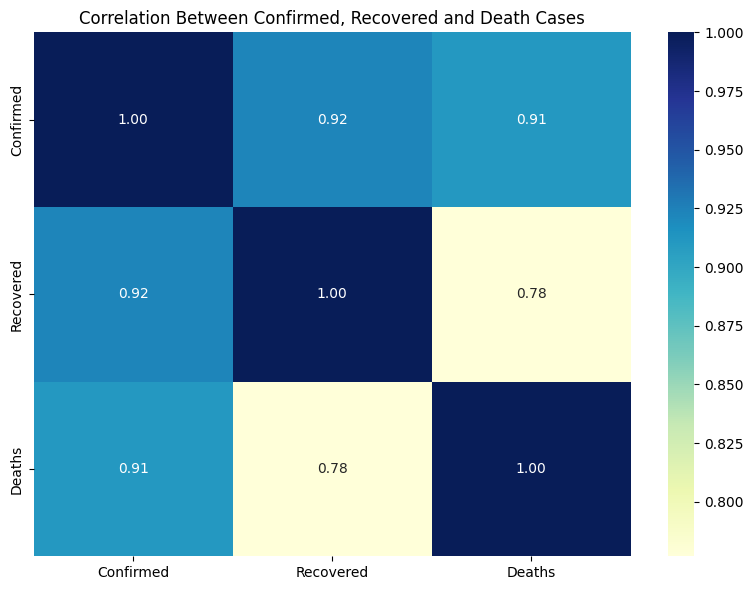

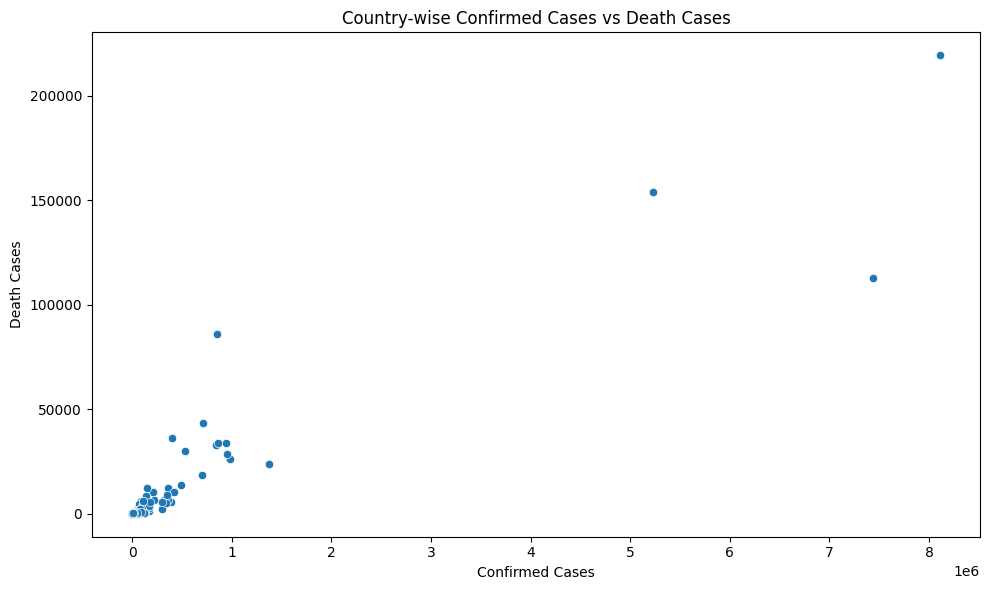

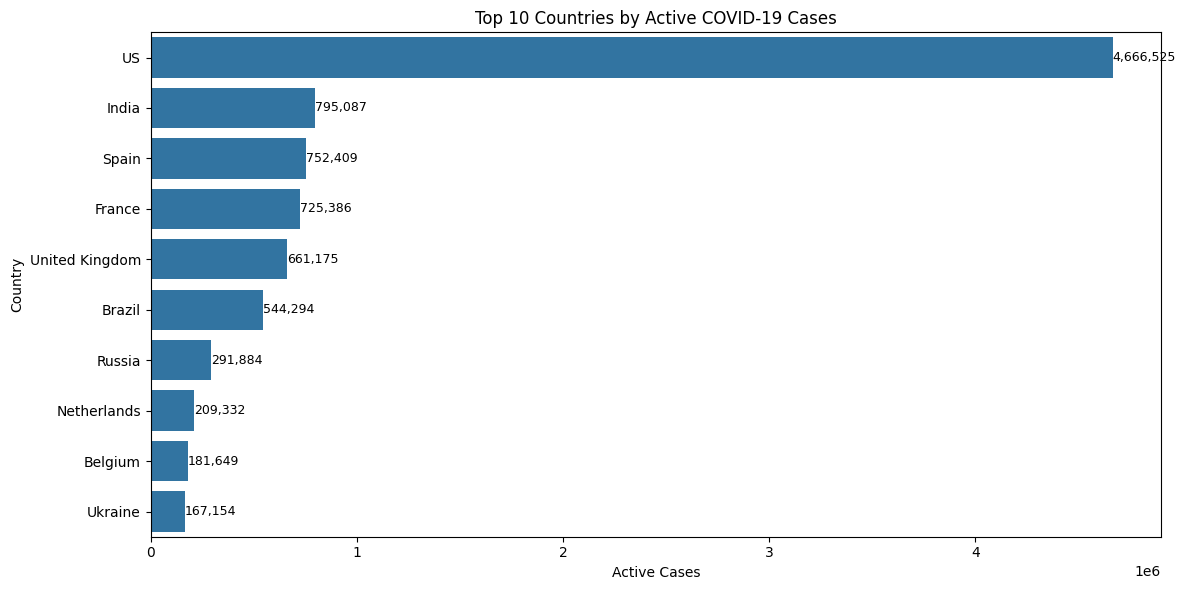

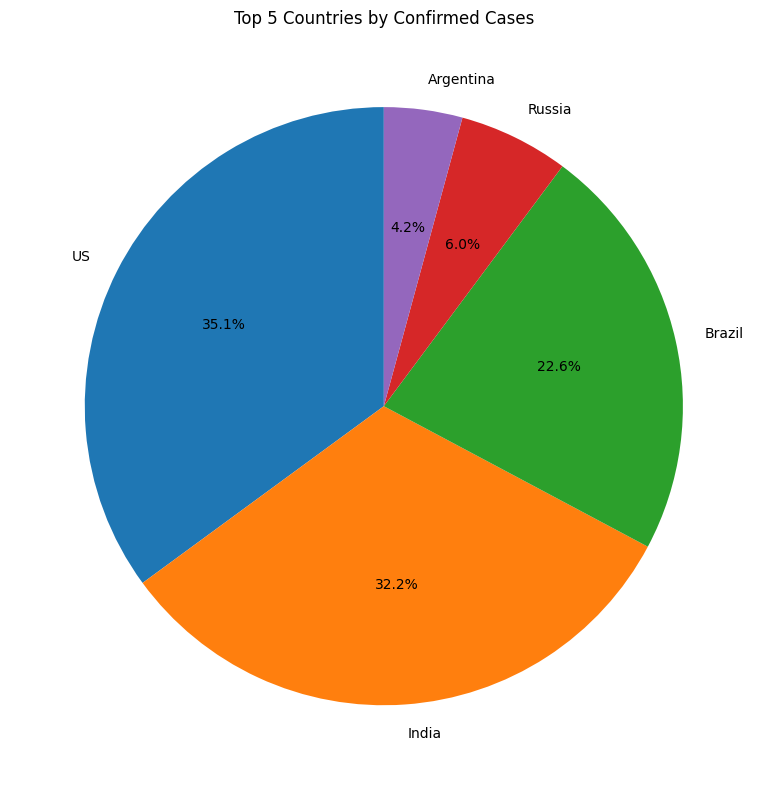

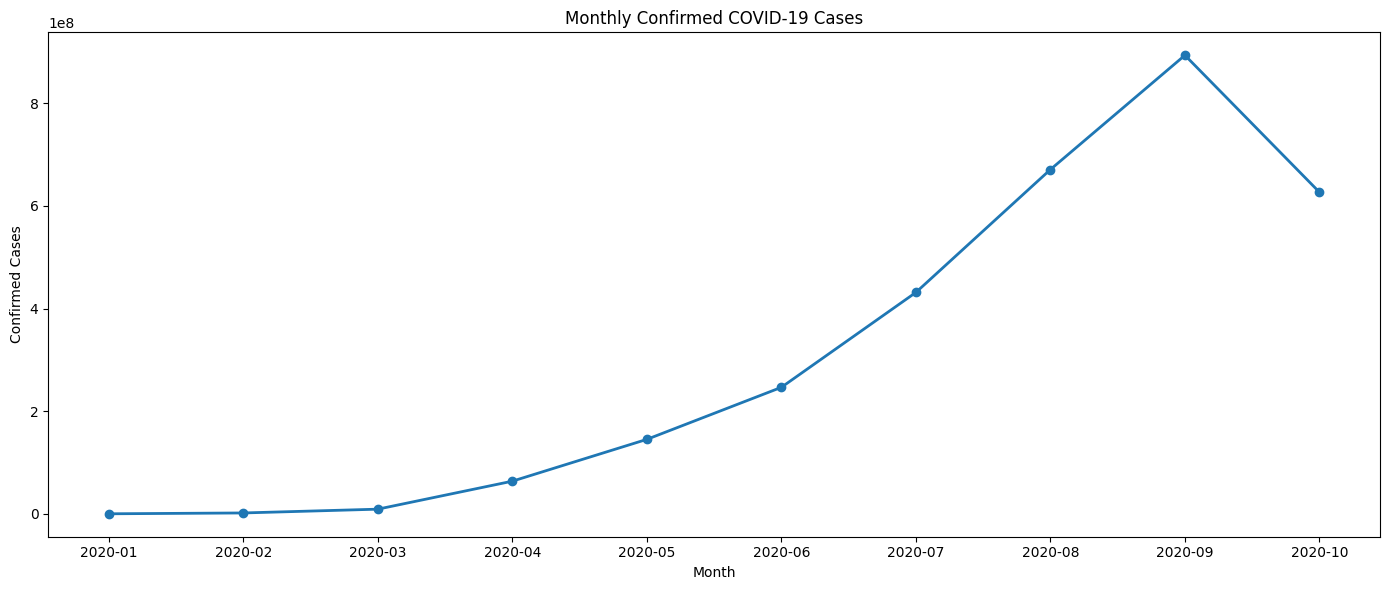

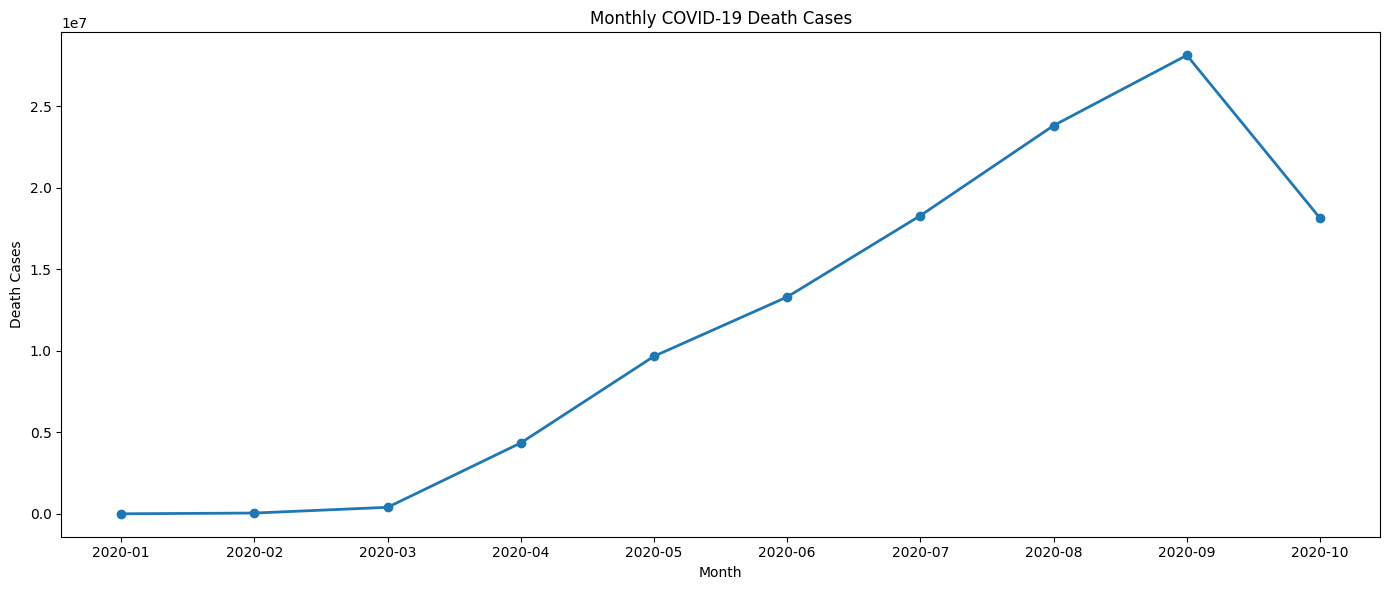

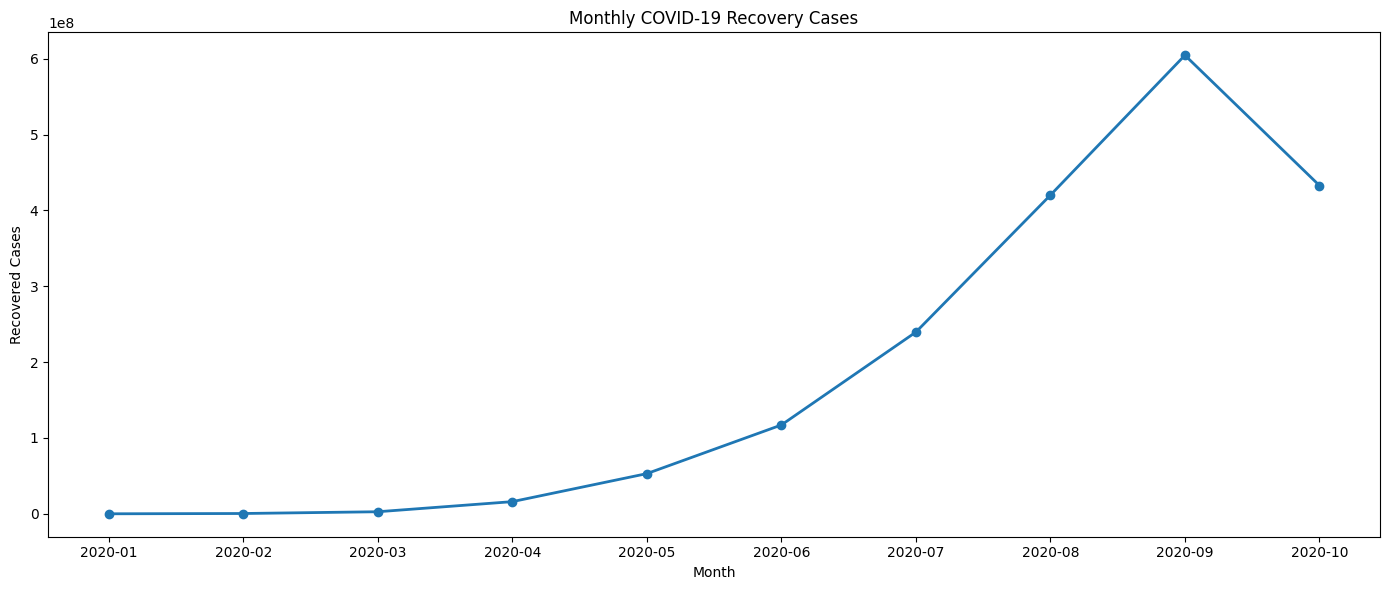


BUSINESS INSIGHTS

1. Country with Highest Confirmed Cases : US
   Total Confirmed Cases : 8,106,384

2. Country with Highest Death Cases : US
   Total Death Cases : 219,286

3. Country with Highest Recovery Cases : India
   Total Recovery Cases : 6,524,595.0

4. Total Confirmed Cases Worldwide : 3,088,782,041
5. Total Recovered Cases Worldwide : 1,885,868,355.0
6. Total Death Cases Worldwide : 116,066,400

7. Overall Recovery Rate : 61.06%
8. Overall Death Rate : 3.76%

9. Total Countries in Dataset : 189
10. Dataset Covers : 2020-01-22 to 2020-10-17

Project Completed Successfully!


In [1]:
# ==========================================================
# COVID-19 DATA ANALYSIS PROJECT
#
# Author      : Pooja Oswal
# Dataset     : Kaggle COVID-19 Time Series Dataset
# Language    : Python
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline


def main():

    print("=" * 70)
    print("COVID-19 DATA ANALYSIS PROJECT")
    print("=" * 70)

    # ---------------------------------------------------------
    # Load Dataset
    # ---------------------------------------------------------

    df = pd.read_csv("time-series-19-covid-combined.csv")

    print("\nDataset Loaded Successfully")

    # ---------------------------------------------------------
    # Basic Information
    # ---------------------------------------------------------

    print("\n========== FIRST FIVE ROWS ==========")
    print(df.head())

    print("\n========== LAST FIVE ROWS ==========")
    print(df.tail())

    print("\n========== DATASET SHAPE ==========")
    print(df.shape)

    print("\n========== COLUMN NAMES ==========")
    print(df.columns)

    print("\n========== DATA TYPES ==========")
    print(df.dtypes)

    print("\n========== DATASET INFO ==========")
    df.info()

    print("\n========== STATISTICAL SUMMARY ==========")
    print(df.describe())

    # ---------------------------------------------------------
    # Missing Values Before Cleaning
    # ---------------------------------------------------------

    print("\n========== MISSING VALUES BEFORE CLEANING ==========")
    print(df.isnull().sum())

    # ---------------------------------------------------------
    # Handle Missing Values
    # ---------------------------------------------------------

    df["Province/State"] = df["Province/State"].fillna("Unknown")
    df["Recovered"] = df["Recovered"].fillna(0)

    print("\n========== MISSING VALUES AFTER CLEANING ==========")
    print(df.isnull().sum())

    # ---------------------------------------------------------
    # Duplicate Rows
    # ---------------------------------------------------------

    duplicates = df.duplicated().sum()

    print("\nDuplicate Rows Before Cleaning :", duplicates)

    if duplicates > 0:
        df.drop_duplicates(inplace=True)
        print("Duplicate Rows Removed")
    else:
        print("No Duplicate Rows Found")

    print("Duplicate Rows After Cleaning :", df.duplicated().sum())

    # ---------------------------------------------------------
    # Convert Date
    # ---------------------------------------------------------

    df["Date"] = pd.to_datetime(df["Date"])

    print("\n========== FINAL DATASET ==========")
    print(df.head())

    # ==========================================================
    # EXPLORATORY DATA ANALYSIS (EDA)
    # ==========================================================

    if not os.path.exists("images"):
        os.makedirs("images")

    # ----------------------------------------------------------
    # Graph 1 : Top 10 Countries by Confirmed Cases
    # ----------------------------------------------------------

    top_confirmed = (
        df.groupby("Country/Region")["Confirmed"]
        .max()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,6))

    ax = sns.barplot(
        x=top_confirmed.values,
        y=top_confirmed.index
    )

    plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
    plt.xlabel("Confirmed Cases")
    plt.ylabel("Country")

    for i, value in enumerate(top_confirmed.values):
        ax.text(
            value,
            i,
            f"{value:,}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        "images/top10_confirmed_cases.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 2 : Top 10 Countries by Death Cases
    # ----------------------------------------------------------

    top_deaths = (
        df.groupby("Country/Region")["Deaths"]
        .max()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,6))

    ax = sns.barplot(
        x=top_deaths.values,
        y=top_deaths.index
    )

    plt.title("Top 10 Countries by COVID-19 Death Cases")
    plt.xlabel("Death Cases")
    plt.ylabel("Country")

    for i, value in enumerate(top_deaths.values):
        ax.text(
            value,
            i,
            f"{value:,}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        "images/top10_death_cases.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 3 : Top 10 Countries by Recovered Cases
    # ----------------------------------------------------------

    top_recovered = (
        df.groupby("Country/Region")["Recovered"]
        .max()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,6))

    ax = sns.barplot(
        x=top_recovered.values,
        y=top_recovered.index
    )

    plt.title("Top 10 Countries by COVID-19 Recovered Cases")
    plt.xlabel("Recovered Cases")
    plt.ylabel("Country")

    for i, value in enumerate(top_recovered.values):
        ax.text(
            value,
            i,
            f"{value:,}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        "images/top10_recovered_cases.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 4 : Daily Confirmed Cases Trend
    # ----------------------------------------------------------

    daily_cases = df.groupby("Date")["Confirmed"].sum()

    plt.figure(figsize=(15,6))

    plt.plot(
        daily_cases.index,
        daily_cases.values,
        linewidth=2
    )

    plt.title("Worldwide Daily Confirmed COVID-19 Cases")
    plt.xlabel("Date")
    plt.ylabel("Confirmed Cases")

    plt.tight_layout()

    plt.savefig(
        "images/daily_confirmed_trend.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    # ----------------------------------------------------------
    # Graph 5 : Daily Death Trend
    # ----------------------------------------------------------

    daily_deaths = df.groupby("Date")["Deaths"].sum()

    plt.figure(figsize=(15,6))

    plt.plot(
        daily_deaths.index,
        daily_deaths.values,
        linewidth=2
    )

    plt.title("Worldwide Daily COVID-19 Death Cases")
    plt.xlabel("Date")
    plt.ylabel("Death Cases")

    plt.tight_layout()

    plt.savefig(
        "images/daily_death_trend.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 6 : Daily Recovery Trend
    # ----------------------------------------------------------

    daily_recovered = df.groupby("Date")["Recovered"].sum()

    plt.figure(figsize=(15,6))

    plt.plot(
        daily_recovered.index,
        daily_recovered.values,
        linewidth=2
    )

    plt.title("Worldwide Daily COVID-19 Recovered Cases")
    plt.xlabel("Date")
    plt.ylabel("Recovered Cases")

    plt.tight_layout()

    plt.savefig(
        "images/daily_recovered_trend.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 7 : Correlation Heatmap
    # ----------------------------------------------------------

    plt.figure(figsize=(8,6))

    sns.heatmap(
        df[["Confirmed", "Recovered", "Deaths"]].corr(),
        annot=True,
        cmap="YlGnBu",
        fmt=".2f"
    )

    plt.title("Correlation Between Confirmed, Recovered and Death Cases")

    plt.tight_layout()

    plt.savefig(
        "images/correlation_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 8 : Country-wise Confirmed vs Death Cases
    # ----------------------------------------------------------

    country_data = (
        df.groupby("Country/Region")[["Confirmed", "Deaths"]]
        .max()
        .reset_index()
    )

    plt.figure(figsize=(10,6))

    sns.scatterplot(
        data=country_data,
        x="Confirmed",
        y="Deaths"
    )

    plt.title("Country-wise Confirmed Cases vs Death Cases")
    plt.xlabel("Confirmed Cases")
    plt.ylabel("Death Cases")

    plt.tight_layout()

    plt.savefig(
        "images/country_confirmed_vs_deaths.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    # ----------------------------------------------------------
    # Graph 9 : Top 10 Countries by Active Cases
    # ----------------------------------------------------------

    country_active = (
        df.groupby("Country/Region")[["Confirmed", "Recovered", "Deaths"]]
        .max()
    )

    country_active["Active"] = (
        country_active["Confirmed"]
        - country_active["Recovered"]
        - country_active["Deaths"]
    )

    top_active = (
        country_active["Active"]
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,6))

    ax = sns.barplot(
        x=top_active.values,
        y=top_active.index
    )

    plt.title("Top 10 Countries by Active COVID-19 Cases")
    plt.xlabel("Active Cases")
    plt.ylabel("Country")

    for i, value in enumerate(top_active.values):
        ax.text(
            value,
            i,
            f"{int(value):,}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        "images/top10_active_cases.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 10 : Top 5 Countries by Confirmed Cases
    # ----------------------------------------------------------

    top5 = (
        df.groupby("Country/Region")["Confirmed"]
        .max()
        .sort_values(ascending=False)
        .head(5)
    )

    plt.figure(figsize=(8,8))

    plt.pie(
        top5.values,
        labels=top5.index,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title("Top 5 Countries by Confirmed Cases")

    plt.tight_layout()

    plt.savefig(
        "images/top5_confirmed_pie.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 11 : Monthly Confirmed Cases
    # ----------------------------------------------------------

    monthly_confirmed = (
        df.groupby(df["Date"].dt.to_period("M"))["Confirmed"]
        .sum()
    )

    plt.figure(figsize=(14,6))

    plt.plot(
        monthly_confirmed.index.astype(str),
        monthly_confirmed.values,
        marker="o",
        linewidth=2
    )

    plt.title("Monthly Confirmed COVID-19 Cases")
    plt.xlabel("Month")
    plt.ylabel("Confirmed Cases")

    plt.tight_layout()

    plt.savefig(
        "images/monthly_confirmed.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 12 : Monthly Death Cases
    # ----------------------------------------------------------

    monthly_deaths = (
        df.groupby(df["Date"].dt.to_period("M"))["Deaths"]
        .sum()
    )

    plt.figure(figsize=(14,6))

    plt.plot(
        monthly_deaths.index.astype(str),
        monthly_deaths.values,
        marker="o",
        linewidth=2
    )

    plt.title("Monthly COVID-19 Death Cases")
    plt.xlabel("Month")
    plt.ylabel("Death Cases")

    plt.tight_layout()

    plt.savefig(
        "images/monthly_deaths.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ----------------------------------------------------------
    # Graph 13 : Monthly Recovery Cases
    # ----------------------------------------------------------

    monthly_recovered = (
        df.groupby(df["Date"].dt.to_period("M"))["Recovered"]
        .sum()
    )

    plt.figure(figsize=(14,6))

    plt.plot(
        monthly_recovered.index.astype(str),
        monthly_recovered.values,
        marker="o",
        linewidth=2
    )

    plt.title("Monthly COVID-19 Recovery Cases")
    plt.xlabel("Month")
    plt.ylabel("Recovered Cases")

    plt.tight_layout()

    plt.savefig(
        "images/monthly_recovered.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    # ==========================================================
    # BUSINESS INSIGHTS
    # ==========================================================

    print("\n" + "=" * 70)
    print("BUSINESS INSIGHTS")
    print("=" * 70)

    # ----------------------------------------------------------
    # Highest Confirmed Cases
    # ----------------------------------------------------------

    highest_confirmed = (
        df.groupby("Country/Region")["Confirmed"]
        .max()
    )

    print(f"\n1. Country with Highest Confirmed Cases : {highest_confirmed.idxmax()}")
    print(f"   Total Confirmed Cases : {highest_confirmed.max():,}")

    # ----------------------------------------------------------
    # Highest Death Cases
    # ----------------------------------------------------------

    highest_deaths = (
        df.groupby("Country/Region")["Deaths"]
        .max()
    )

    print(f"\n2. Country with Highest Death Cases : {highest_deaths.idxmax()}")
    print(f"   Total Death Cases : {highest_deaths.max():,}")

    # ----------------------------------------------------------
    # Highest Recovery Cases
    # ----------------------------------------------------------

    highest_recovered = (
        df.groupby("Country/Region")["Recovered"]
        .max()
    )

    print(f"\n3. Country with Highest Recovery Cases : {highest_recovered.idxmax()}")
    print(f"   Total Recovery Cases : {highest_recovered.max():,}")

    # ----------------------------------------------------------
    # Worldwide Totals
    # ----------------------------------------------------------

    print(f"\n4. Total Confirmed Cases Worldwide : {df['Confirmed'].sum():,}")
    print(f"5. Total Recovered Cases Worldwide : {df['Recovered'].sum():,}")
    print(f"6. Total Death Cases Worldwide : {df['Deaths'].sum():,}")

    # ----------------------------------------------------------
    # Recovery Rate
    # ----------------------------------------------------------

    recovery_rate = (
        df["Recovered"].sum() /
        df["Confirmed"].sum()
    ) * 100

    print(f"\n7. Overall Recovery Rate : {recovery_rate:.2f}%")

    # ----------------------------------------------------------
    # Death Rate
    # ----------------------------------------------------------

    death_rate = (
        df["Deaths"].sum() /
        df["Confirmed"].sum()
    ) * 100

    print(f"8. Overall Death Rate : {death_rate:.2f}%")

    # ----------------------------------------------------------
    # Number of Countries
    # ----------------------------------------------------------

    print(f"\n9. Total Countries in Dataset : {df['Country/Region'].nunique()}")

    # ----------------------------------------------------------
    # Dataset Duration
    # ----------------------------------------------------------

    print(
        f"10. Dataset Covers : "
        f"{df['Date'].min().date()} to {df['Date'].max().date()}"
    )

    print("\nProject Completed Successfully!")

    return df


# ==========================================================
# RUN MAIN FUNCTION
# ==========================================================

df = main()